# WD+MS simulations through the XP selection pipeline

**Question:** which simulated binaries pass the XP chi-squared and component-color selection, and which condition removes them?

This notebook takes WD mass/temperature and MS mass/age/metallicity, converts them to component photometry with **WD_models + PARSEC**, adds the two linear XP spectra, and fits both single-star and WD+MS hypotheses. Repeated noise draws give a selection fraction for each input system.

The example has nine systems and ten noise draws per system. Replace the input CSV with your simulation table; the remaining cells run in order.

**Before running:** use Python 3.10+, install `python -m pip install -r requirements-notebook.txt`, and start `jupyter lab wdms_selection.ipynb` from the repository directory. The physical-parameter route downloads WD_models once if it is missing. The XP emulator and PARSEC subset are already included.

We will inspect component photometry, one spectrum and its two fits, the cumulative selection counts, and selection fractions in the combined color–magnitude diagram. The last experiment changes the quality threshold without refitting.

In [1]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
from photometry import component_photometry
from wdms_xp import XPModel, add_noise, selection

INPUT_CSV = ROOT / "examples" / "mock_parameters.csv"
WD_MODELS_PATH = ROOT / "external" / "WD_models"
ATMOSPHERE = "H"
SNR = 20.0                 # Per XP pixel; sigma = abs(flux) / SNR.
N_DRAWS = 10               # Increase for a less noisy selection fraction.
SEED = 42
CHI2_KIND = "reduced"      # Alternatively: "total" with CHI2_MAX = 1000.
CHI2_MAX = 20.0
OUTPUT = ROOT / "results_notebook"
OUTPUT.mkdir(exist_ok=True)

model = XPModel()
plt.rcParams.update({"font.size": 10, "figure.dpi": 120})

## 1. Read the simulated binaries

Use one row per binary. Required physical columns are `mass_wd`, `teff_wd`, `mass_ms`, `mh_ms`, and `age_ms_gyr`. Masses are current masses in solar masses, temperature is in K, metallicity is [M/H] in dex, and age is in Gyr. Other simulation columns are retained in the exports.

If component photometry is already available, the same notebook accepts `bp_rp_wd, abs_g_wd, abs_rp_wd, bp_rp_ms, abs_g_ms, abs_rp_ms` instead. These are intrinsic absolute magnitudes/colors.

In [2]:
inputs = pd.read_csv(INPUT_CSV)
inputs = inputs.reset_index(drop=True).rename_axis("input_row")
if "system_id" not in inputs:
    inputs["system_id"] = [f"binary_{i}" for i in inputs.index]
display(inputs)

,system_id,mass_wd,teff_wd,mass_ms,mh_ms,age_ms_gyr
input_row,,,,,,
0,wd04_ms03_cool,0.4,7000,0.3,0.0,4.0
1,wd04_ms03_warm,0.4,12000,0.3,0.0,4.0
2,wd04_ms03_hot,0.4,20000,0.3,0.0,4.0
3,wd06_ms03_cool,0.6,7000,0.3,0.0,4.0
4,wd06_ms03_warm,0.6,12000,0.3,0.0,4.0
5,wd06_ms03_hot,0.6,20000,0.3,0.0,4.0
6,wd06_ms05_cool,0.6,7000,0.5,0.0,4.0
7,wd06_ms05_warm,0.6,12000,0.5,0.0,4.0
8,wd06_ms05_hot,0.6,20000,0.5,0.0,4.0


## 2. Physical parameters → component photometry

WD_models maps WD mass and temperature to gravity and bolometric magnitude with Bédard2020 cooling tracks at low/intermediate mass and ONe tracks at high mass. Its atmosphere tables then give Gaia EDR3 BP, G, and RP. PARSEC gives the MS magnitudes by interpolation in current mass, metallicity, and age.

The XP model uses three labels per component: **(BP−RP, M_G, M_RP)**. Rows outside the interpolation grid or XP fitting bounds are reported separately from selection failures.

In [3]:
PHOT_COLUMNS = [f"{label}_{star}" for star in ("wd", "ms")
                for label in ("bp_rp", "abs_g", "abs_rp")]

if all(column in inputs for column in PHOT_COLUMNS):
    wd_labels = inputs[PHOT_COLUMNS[:3]].to_numpy(dtype=float)
    ms_labels = inputs[PHOT_COLUMNS[3:]].to_numpy(dtype=float)
else:
    if not WD_MODELS_PATH.exists():
        WD_MODELS_PATH.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run([
            "git", "clone", "--depth", "1",
            "https://github.com/SihaoCheng/WD_models.git", str(WD_MODELS_PATH),
        ], check=True)
    wd_labels, ms_labels = component_photometry(
        inputs.to_dict("records"), WD_MODELS_PATH, atmosphere=ATMOSPHERE)

truth = inputs.copy()
truth[PHOT_COLUMNS] = np.column_stack([wd_labels, ms_labels])
finite = np.isfinite(truth[PHOT_COLUMNS].to_numpy()).all(axis=1)
supported = np.array([model.in_bounds(wd, ms)
                      for wd, ms in zip(wd_labels, ms_labels)])
truth["status"] = np.where(~finite, "outside_photometry_grid",
                           np.where(supported, "supported", "outside_xp_bounds"))
SUPPORTED_ROWS = np.flatnonzero(supported)
if len(SUPPORTED_ROWS) == 0:
    raise ValueError("No input systems are inside the model grids; inspect truth.")

display(truth[["system_id", *PHOT_COLUMNS, "status"]].round(3))
print(truth["status"].value_counts().to_string())

,system_id,bp_rp_wd,abs_g_wd,abs_rp_wd,bp_rp_ms,abs_g_ms,abs_rp_ms,status
input_row,,,,,,,,
0,wd04_ms03_cool,0.513,12.938,12.608,2.692,10.924,9.784,supported
1,wd04_ms03_warm,-0.038,11.147,11.174,2.692,10.924,9.784,supported
2,wd04_ms03_hot,-0.289,10.065,10.257,2.692,10.924,9.784,supported
3,wd06_ms03_cool,0.513,13.437,13.107,2.692,10.924,9.784,supported
4,wd06_ms03_warm,-0.026,11.682,11.700,2.692,10.924,9.784,supported
5,wd06_ms03_hot,-0.281,10.723,10.909,2.692,10.924,9.784,supported
6,wd06_ms05_cool,0.513,13.437,13.107,2.184,9.093,8.074,supported
7,wd06_ms05_warm,-0.026,11.682,11.700,2.184,9.093,8.074,supported
8,wd06_ms05_hot,-0.281,10.723,10.909,2.184,9.093,8.074,supported


status
supported    9


## 3. One synthetic XP spectrum and its fits

The two component spectra are on the same 10-pc flux scale. **Add linear fluxes, not magnitudes or scaled network outputs.** The example uses independent Gaussian errors with a constant per-pixel SNR; the error vector passed to the fitter is the positive standard deviation.

Both fits use the same noisy spectrum and error vector. Their initialization networks have no access to the simulated component labels. The preview uses its own random generator, so changing which system is plotted does not alter the batch experiment below.

In [4]:
preview_row = SUPPORTED_ROWS[min(1, len(SUPPORTED_ROWS) - 1)]
f_wd = model.spectrum(wd_labels[preview_row])
f_ms = model.spectrum(ms_labels[preview_row])
f_true = f_wd + f_ms
f_observed, sigma = add_noise(f_true, SNR, np.random.default_rng(SEED))
preview_fit = model.fit(f_observed, sigma)
preview_flags = selection(preview_fit, chi2_max=CHI2_MAX, chi2_kind=CHI2_KIND)

comparison = pd.DataFrame({
    "hypothesis": ["single", "WD+MS"],
    "chi2": [preview_fit["chi2_single"], preview_fit["chi2_binary"]],
    "reduced_chi2": [preview_fit["chi2_single_reduced"],
                     preview_fit["chi2_binary_reduced"]],
    "converged": [preview_fit["success_single"], preview_fit["success_binary"]],
})
print("Preview:", truth.loc[preview_row, "system_id"])
display(comparison.round(3))
display(pd.Series(preview_flags, name="passed").to_frame())

Preview: wd04_ms03_warm


,hypothesis,chi2,reduced_chi2,converged
0,single,318.858,5.498,True
1,WD+MS,37.465,0.681,True


,passed
pass_quality,True
pass_improvement,True
pass_contrast_g,True
pass_contrast_rp,True
pass_wd_cmd,True
fit_converged,True
pass_selection,True


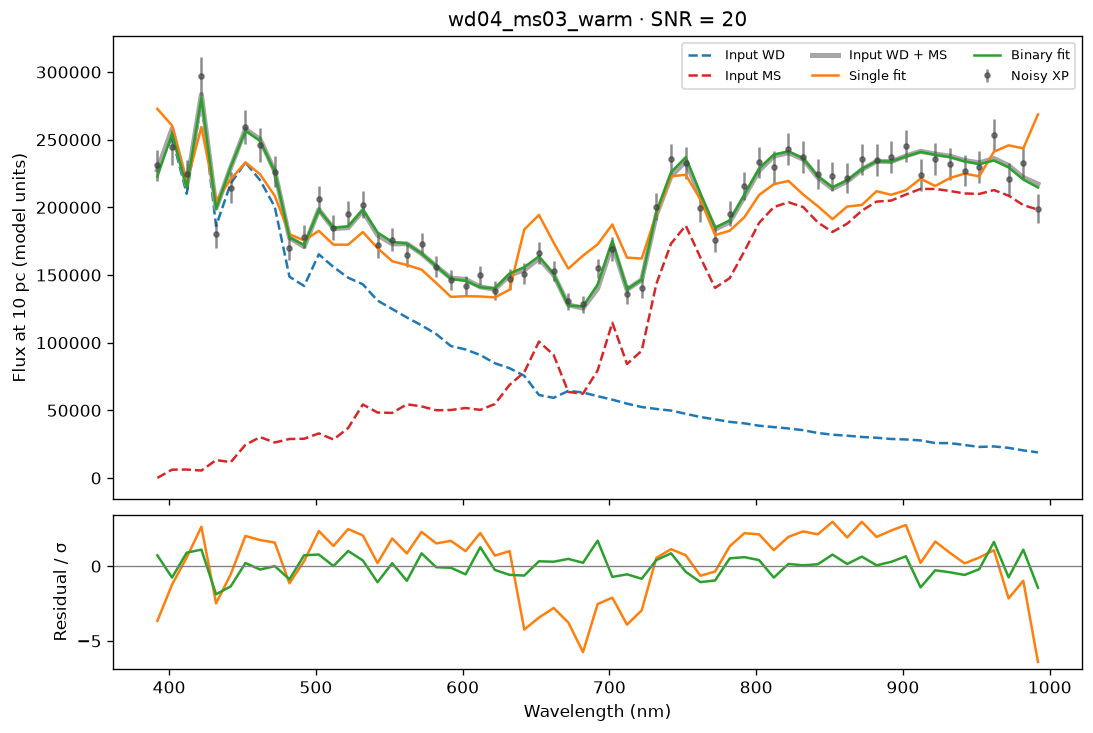

In [5]:
fig, (ax, residual_ax) = plt.subplots(
    2, 1, figsize=(9, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]},
    layout="constrained")
wave = model.wave_nm
ax.plot(wave, f_wd, "--", color="tab:blue", label="Input WD")
ax.plot(wave, f_ms, "--", color="tab:red", label="Input MS")
ax.plot(wave, f_true, color="0.65", lw=3, label="Input WD + MS")
ax.errorbar(wave, f_observed, yerr=sigma, fmt=".", color="0.25",
            alpha=0.6, label="Noisy XP")
for hypothesis, color in [("single", "tab:orange"), ("binary", "tab:green")]:
    ax.plot(wave, preview_fit[f"flux_{hypothesis}"], color=color,
            label=f"{hypothesis.capitalize()} fit")
    residual_ax.plot(wave, (f_observed - preview_fit[f"flux_{hypothesis}"]) / sigma,
                     color=color, label=hypothesis)
residual_ax.axhline(0, color="0.5", lw=0.8)
residual_ax.set(xlabel="Wavelength (nm)", ylabel="Residual / σ")
ax.set(ylabel="Flux at 10 pc (model units)",
       title=f"{truth.loc[preview_row, 'system_id']} · SNR = {SNR:g}")
ax.legend(ncol=3, fontsize=8)
fig.savefig(OUTPUT / "example_xp_fit.png", dpi=180)
plt.show()
plt.close(fig)

## 4. Repeat noise draws and apply the selection

All conditions are evaluated on the **fitted** component labels:

1. Both single and binary reduced chi-squared values are below 20 (default).
2. Total binary chi-squared is smaller than total single chi-squared.
3. The absolute component contrast is ≤2.5 mag in G and in RP.
4. The fitted WD lies below the line `M_G = 9 + 2.5*(BP−RP)` in the CMD, i.e. has a larger numerical M_G.

`pass_selection` requires all five flags. Optimizer convergence is recorded separately. For total chi-squared, set `CHI2_KIND = "total"` and `CHI2_MAX = 1000` in the setup cell and rerun.

In [6]:
rng = np.random.default_rng(SEED)
records, fits, spectra = [], [], []
SCALAR_FIT_KEYS = ["chi2_single", "chi2_binary", "chi2_single_reduced",
                   "chi2_binary_reduced", "success_single", "success_binary",
                   "nfev_single", "nfev_binary", "n_valid"]
for input_row in SUPPORTED_ROWS:
    noiseless = model.binary_spectrum(wd_labels[input_row], ms_labels[input_row])
    for draw in range(N_DRAWS):
        noisy, error = add_noise(noiseless, SNR, rng)
        fit = model.fit(noisy, error)
        flags = selection(fit, chi2_max=CHI2_MAX, chi2_kind=CHI2_KIND)
        record = {
            "input_row": int(input_row), "draw": draw, "snr": SNR,
            "seed": SEED, "chi2_kind": CHI2_KIND, "chi2_max": CHI2_MAX,
            **{key: fit[key] for key in SCALAR_FIT_KEYS}, **flags,
        }
        record.update(zip([f"fit_{key}" for key in PHOT_COLUMNS], fit["labels_binary"]))
        record.update(zip([f"fit_single_{key}" for key in ("bp_rp", "abs_g", "abs_rp")],
                          fit["labels_single"]))
        records.append(record)
        fits.append(fit)
        spectra.append([noiseless, noisy, error, fit["flux_single"], fit["flux_binary"]])

runs = pd.DataFrame(records)
print(f"Fitted {len(SUPPORTED_ROWS)} supported systems × {N_DRAWS} draws = {len(runs)} spectra.")
print(f"Both fits converged: {runs['fit_converged'].sum()} / {len(runs)}")
display(runs[["input_row", "draw", "chi2_single_reduced", "chi2_binary_reduced",
              "pass_selection"]].head(10).round(3))

Fitted 9 supported systems × 10 draws = 90 spectra.
Both fits converged: 90 / 90


,input_row,draw,chi2_single_reduced,chi2_binary_reduced,pass_selection
0,0,0,4.370,0.706,False
1,0,1,4.181,0.586,False
2,0,2,4.844,1.056,False
3,0,3,4.849,1.001,False
4,0,4,4.266,1.088,False
5,0,5,5.306,1.005,True
6,0,6,4.820,1.068,True
7,0,7,3.643,0.946,False
8,0,8,4.711,1.120,False
9,0,9,4.699,1.022,False


## 5. Which cut removes each system?

The per-system selection fraction is the number of accepted draws divided by the number tried. With only ten draws it is a coarse noise-response estimate. The following flag fractions measure each condition individually; the bar chart then applies them cumulatively in the displayed order.

In [7]:
CUT_NAMES = {
    "pass_quality": "χ² quality",
    "pass_improvement": "Binary improves χ²",
    "pass_contrast_g": "G contrast",
    "pass_contrast_rp": "RP contrast",
    "pass_wd_cmd": "WD CMD",
}
summary = runs.groupby("input_row").agg(
    n_draws=("draw", "size"),
    n_selected=("pass_selection", "sum"),
    selection_fraction=("pass_selection", "mean"),
    converged_fraction=("fit_converged", "mean"),
)
for flag in CUT_NAMES:
    summary[flag + "_fraction"] = runs.groupby("input_row")[flag].mean()
summary = truth.join(summary)
display(summary[["system_id", "status", "n_draws", "n_selected", "selection_fraction",
                 *[flag + "_fraction" for flag in CUT_NAMES]]].round(2))

keep = np.ones(len(runs), dtype=bool)
cumulative_counts = [len(runs)]
for flag in CUT_NAMES:
    keep &= runs[flag].to_numpy(dtype=bool)
    cumulative_counts.append(int(keep.sum()))
print(f"Selected draws: {keep.sum()} / {len(runs)} supported draws")

,system_id,status,n_draws,n_selected,selection_fraction,pass_quality_fraction,pass_improvement_fraction,pass_contrast_g_fraction,pass_contrast_rp_fraction,pass_wd_cmd_fraction
input_row,,,,,,,,,,
0,wd04_ms03_cool,supported,10,2,0.2,1.0,1.0,1.0,0.2,1.0
1,wd04_ms03_warm,supported,10,10,1.0,1.0,1.0,1.0,1.0,1.0
2,wd04_ms03_hot,supported,10,0,0.0,0.0,1.0,1.0,1.0,1.0
3,wd06_ms03_cool,supported,10,0,0.0,1.0,1.0,0.2,0.0,1.0
4,wd06_ms03_warm,supported,10,10,1.0,1.0,1.0,1.0,1.0,1.0
5,wd06_ms03_hot,supported,10,3,0.3,0.3,1.0,1.0,1.0,1.0
6,wd06_ms05_cool,supported,10,0,0.0,1.0,1.0,0.0,0.0,1.0
7,wd06_ms05_warm,supported,10,0,0.0,1.0,1.0,0.4,0.0,1.0
8,wd06_ms05_hot,supported,10,5,0.5,1.0,1.0,1.0,0.5,1.0


Selected draws: 30 / 90 supported draws


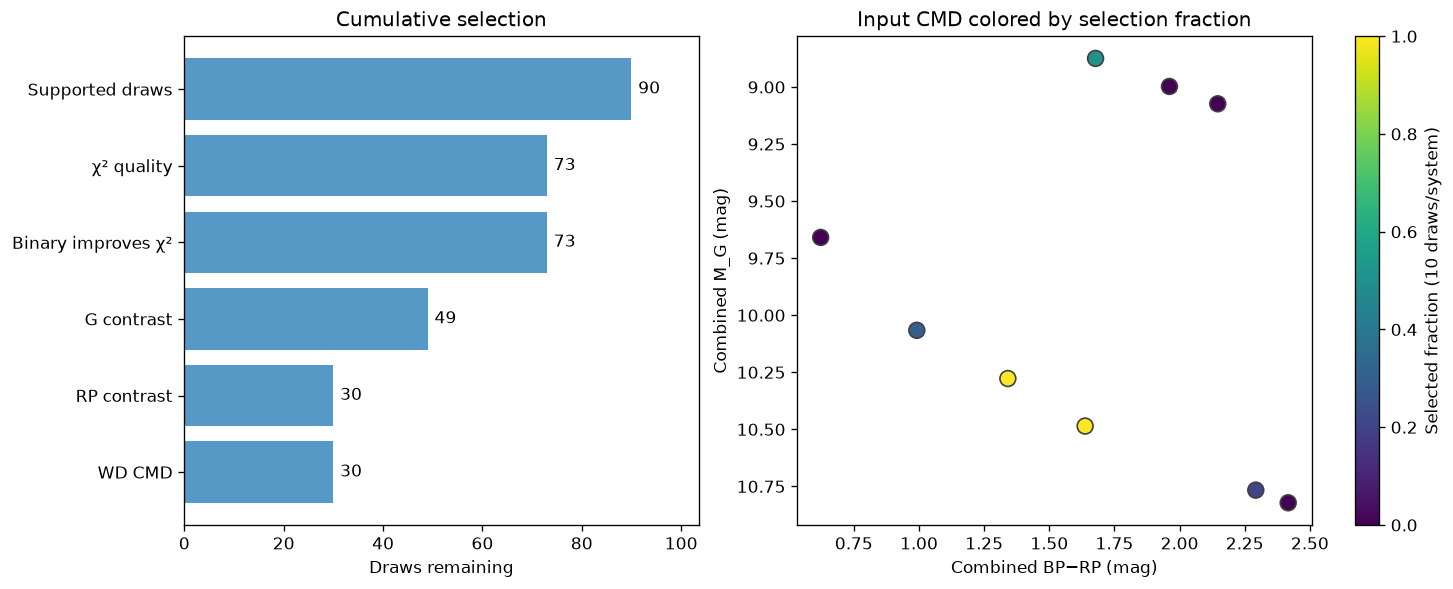

In [8]:
def combined_magnitude(m1, m2):
    return -2.5 * np.log10(10**(-0.4 * m1) + 10**(-0.4 * m2))

# BP is (BP-RP) + RP for each component.
total_bp = combined_magnitude(wd_labels[:, 0] + wd_labels[:, 2],
                              ms_labels[:, 0] + ms_labels[:, 2])
total_rp = combined_magnitude(wd_labels[:, 2], ms_labels[:, 2])
total_g = combined_magnitude(wd_labels[:, 1], ms_labels[:, 1])
summary["input_combined_bp_rp"] = total_bp - total_rp
summary["input_combined_abs_g"] = total_g

fig, (counts_ax, cmd_ax) = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
positions = np.arange(len(cumulative_counts))
counts_ax.barh(positions, cumulative_counts, color="tab:blue", alpha=0.75)
counts_ax.set_yticks(positions, ["Supported draws", *CUT_NAMES.values()])
counts_ax.invert_yaxis()
counts_ax.set(xlabel="Draws remaining", title="Cumulative selection")
counts_ax.set_xlim(0, max(cumulative_counts) * 1.15)
for y, count in zip(positions, cumulative_counts):
    counts_ax.text(count + max(cumulative_counts) * 0.015, y, str(count), va="center")

shown = summary.loc[SUPPORTED_ROWS]
points = cmd_ax.scatter(shown["input_combined_bp_rp"], shown["input_combined_abs_g"],
                        c=shown["selection_fraction"], cmap="viridis", vmin=0, vmax=1,
                        s=90, edgecolor="0.25")
cmd_ax.invert_yaxis()
cmd_ax.set(xlabel="Combined BP−RP (mag)", ylabel="Combined M_G (mag)",
           title="Input CMD colored by selection fraction")
fig.colorbar(points, ax=cmd_ax, label=f"Selected fraction ({N_DRAWS} draws/system)")
fig.savefig(OUTPUT / "selection_response.png", dpi=180)
plt.show()
plt.close(fig)

## 6. Save results for the manuscript analysis

The truth and per-system tables include every input row. Unsupported systems have no selection fraction. The per-draw table and spectral archive contain supported systems only, identified by the zero-based `input_row` and `draw` columns.

In [9]:
truth.to_csv(OUTPUT / "component_photometry.csv", index=True)
summary.to_csv(OUTPUT / "selection_by_system.csv", index=True)
run_export = runs.merge(truth.reset_index(), on="input_row", how="left", validate="many_to_one")
run_export.to_csv(OUTPUT / "selection_by_draw.csv", index=False)
np.savez_compressed(
    OUTPUT / "spectra.npz", wave_nm=model.wave_nm,
    input_row=runs["input_row"].to_numpy(), draw=runs["draw"].to_numpy(),
    spectra=np.asarray(spectra),
    spectrum_order=np.array(["noiseless", "noisy", "sigma", "single_fit", "binary_fit"]),
)
print("Saved to:", OUTPUT.relative_to(ROOT))
for filename in sorted(OUTPUT.iterdir()):
    print(" ", filename.name)

Saved to: results_notebook
  component_photometry.csv
  example_xp_fit.png
  selection_by_draw.csv
  selection_by_system.csv
  selection_response.png
  spectra.npz


## 7. Exercise: does stronger binary evidence always help selection?

A binary can improve chi-squared substantially and still fail the upper limit on the **single-star** chi-squared. Compare reduced limits of 20 and 50 on exactly the same fitted spectra. Which systems gain accepted draws? The answer cell below reuses the fits; it does not synthesize new noise or rerun optimization.

In [10]:
threshold_comparison = truth[["system_id", "status"]].copy()
for limit in [20.0, 50.0]:
    accepted = [selection(fit, chi2_max=limit, chi2_kind="reduced")["pass_selection"]
                for fit in fits]
    fraction = pd.Series(accepted).groupby(runs["input_row"]).mean()
    threshold_comparison[f"fraction_reduced_chi2_lt_{limit:g}"] = fraction

display(threshold_comparison.round(2))

,system_id,status,fraction_reduced_chi2_lt_20,fraction_reduced_chi2_lt_50
input_row,,,,
0,wd04_ms03_cool,supported,0.2,0.2
1,wd04_ms03_warm,supported,1.0,1.0
2,wd04_ms03_hot,supported,0.0,1.0
3,wd06_ms03_cool,supported,0.0,0.0
4,wd06_ms03_warm,supported,1.0,1.0
5,wd06_ms03_hot,supported,0.3,1.0
6,wd06_ms05_cool,supported,0.0,0.0
7,wd06_ms05_warm,supported,0.0,0.0
8,wd06_ms05_hot,supported,0.5,0.5


The systems whose fraction increases are removed by the default quality limit in some draws even though the other conditions pass. Systems that do not increase may be limited by contrast, WD CMD position, or a still larger chi-squared.

**Optional extension:** rerun with `SNR = 50` or a larger `N_DRAWS`. Increasing SNR also increases the penalty for a poor single-star fit, so the selection fraction need not increase monotonically. Keep the threshold convention fixed when comparing populations.

## Limitations and references

- This is a conditional selection-response experiment within the supported model grids. The same emulator generates and fits the XP spectra. It does not calibrate survey completeness, emulator mismatch, Gaia XP availability, or the parent-sample/eclipsing-binary discovery cuts.
- Spectra are static, intrinsic, and at 10 pc. Independent pixel noise omits Gaia wavelength covariance. Gaia XP is based on mean observations; eclipse sampling, irradiation, and phase-dependent spectra need a separate forward model.
- WD_models imposes its cooling-track mass–radius relation. PARSEC describes ordinary main-sequence stars; post-interaction companions and nonstandard WD atmospheres may need other physical models.
- The manuscript table, archived notebook, and published catalogue use quality cuts that have not been reconciled into one exact catalogue-reproduction rule. This notebook states and varies the thresholds explicitly.

Model provenance and exact selection definitions are in [README.md](README.md). Cite [the WDMS catalogue](https://zenodo.org/records/14411003), [WD_models and its model references](https://github.com/SihaoCheng/WD_models), and [PARSEC](https://stev.oapd.inaf.it/cgi-bin/cmd). See also [Gaia DR3 software tools](https://www.cosmos.esa.int/web/gaia/dr3-software-tools) for working with Gaia XP products.